# 📖 Grids

In Lagrangian ocean analysis, virtual particle tracking requires the accurate interpolation of physical properties (flow velocities and tracer properties) to particle locations. The underlying data that forces the particle movement will likely be defined on a discretised grid. Parcels can natively handle two styles of grids; structured and unstructured, where Parcels `Field` objects exist on a (structured) `parcels.XGrid` and conform to [SGRID](https://sgrid.github.io/sgrid/) conventions, or on a (unstructured) `parcels.Uxgrid` and conform to [UGRID](https://ugrid-conventions.github.io/ugrid-conventions/) conventions. Here we describe these grids on a conceptual level.

Under the hood, every `Field` in a `FieldSet` has a `grid` attribute. This `grid` stores the spatial and temporal information of the Field coordinates. The number of Grids in a FieldSet is thus always smaller or equal to the number of Field objects; and this is what the "grid number" column in `FieldSet.describe()` refers to.

```{note}
Parcels comes ready with a range of `convert` functions which will convert your `xarray` dataset into a SGRID or UGRID compliant dataset. We currently provide support for NEMO, MITgcm, CROCO, FESOM, and SCHISM models. For other models, you can create your own `convert` function, or reach out on our discussion board for help.
```

## Structured grids

A structured grid is composed of quadrilateral elements, that are indexed using logical 2D or 3D indices, like $(i,j,k)$. In `xarray` terminology, these indices correspond to `dimensions`. For example, in NEMO datasets, $(x,y)$ typically define these dimensions horizontally, where the physical coordinates are $(glamf, gphif)$. A major benefit of structured grids is that grid cell neighbours are easily found by decrementing or incrementing these dimensions. However, in Parcels we either perform a binary search in the case of 1-dimensional coordinates, or use a hash table in the case of 2/3-dimensional coordinates.

There are two styles of structured grids, rectilinear and curvilinear, as shown in Figure 1.

1. Rectilinear grids are typically aligned with the coordinate axes (that is, there is a one-to-one mapping between the dimensions and the physical coordinate space), making them simple and computationally efficient to query. However, they're limited by the fact that it is difficult to resolve complex coastlines without high resolution, and they suffer from singularities in the flow fields at the poles where the grid lines converge.

2. Curvilinear grids allow for curved grid lines, which allow for better representation of coastlines. They often move the poles onto land to avoid singularities occuring in the ocean. However, they become trickier to work with, as the spatial positions of their vertices (their ["coordinates" in xarray-parlance](https://docs.xarray.dev/en/latest/user-guide/terminology.html#term-Coordinate)) are stored in separate 2D arrays, and moving to an eastward neighbour is not as simple as incrementing the $i$-th dimension by 1.

![**Figure 1 - Grid discretisations handled by Parcels. In the horizontal plane; (a) rectilinear, (b) curvilinear. In the vertical plane; (c) z-levels, (d) sigma-levels. Adapted from [Parcels v2.0 paper](https://doi.org/10.5194/gmd-12-3571-2019)**](../../_static/grid_discretisation.png)

## Unstructured grids

TODO: For Joe.

## How your data may be defined

Regardless of your grid type, how your data is defined on your grid is equally important. Here, we will describe how you can interpret your data at a very general level, and the concept applies for any $n$-gon ($n$-sided polygon with $n \ge 3$).

### Nodes, edges, and faces

Let's assume we have a simple 2D rectilinear grid. The grid is composed of a number of nodes (or vertices), connected by edges, which together construct grid cells and grid cell faces. In Figure 2, we draw a simple grid cell. Here, your data may be defined on the corners of the grid cell (the nodes/vertices), at the centre of the cell face, or across a cell edge.

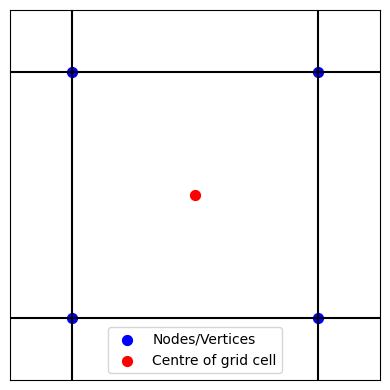

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, RegularGridInterpolator

# Ignore RuntimeWarnings that arise in plotting
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.figure(figsize=(4, 4))
plt.axvline(x=0, color='black')
plt.axvline(x=1, color='black')
plt.axhline(y=0, color='black')
plt.axhline(y=1, color='black')
plt.scatter([0,0,1,1], [0,1,0,1], color='blue', s=50, label='Nodes/Vertices')
plt.scatter([0.5], [0.5], color='red', s=50, label='Centre of grid cell')
plt.xlim(-0.25, 1.25)
plt.ylim(-0.25, 1.25)
plt.xticks([])
plt.yticks([])
plt.legend()
plt.tight_layout()
plt.show()

Figure 2 - A simple grid cell. Blue circles denote nodes (or vertices) of the grid cell. The red circle denotes the centre of the cell face.

You will need to make several assumptions about your data. Your data may represent a point-wise "sample" of some field. For example, velocity data may be defined at the nodes of your grid, and a typical assumption to make is that you can bi-linearly interpolate these data points to your particle positions. In such an example, your velocity field may look like Figure 3. Bi-linear interpolation ensures continuity of the velocity at the cell boundaries, however, it does not ensure a smooth transition.


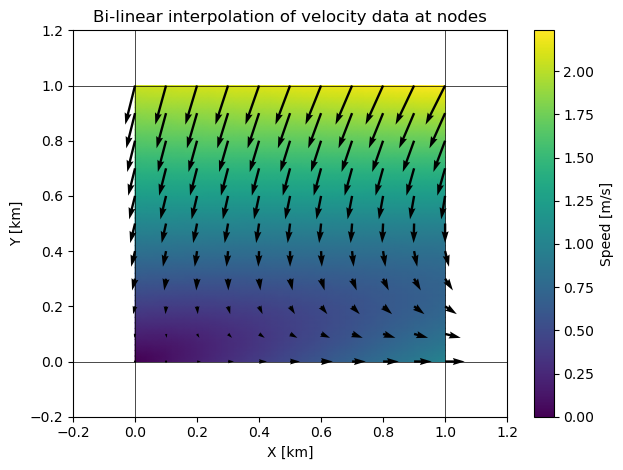

In [32]:
# Construct dummy data for velocity field at the nodes of a single grid cell
xcoords, ycoords = np.linspace(0,1,2), np.linspace(0,1,2)

u_data = np.array([[0, -0.5], [1, -1]])
v_data = np.array([[0, -2], [0, -2]])

interp_u = RegularGridInterpolator((xcoords, ycoords), u_data, method='linear')

interp_v = RegularGridInterpolator((xcoords, ycoords), v_data, method='linear')

interp_xx, interp_yy  = np.linspace(0,1,51), np.linspace(0,1,51)
interp_xx, interp_yy = np.meshgrid(interp_xx, interp_yy, indexing='ij')

eval_points = np.stack([interp_xx.ravel(), interp_yy.ravel()], axis=-1)

interp_u_data = interp_u(eval_points).reshape(51, 51)
interp_v_data = interp_v(eval_points).reshape(51, 51)

interp_speed_data = np.sqrt(interp_u_data**2 + interp_v_data**2)

# Plot the interpolated velocity vectors and speed data
mm=5
plt.axhline(0, linewidth=0.5, color='k')
plt.axvline(0, linewidth=0.5, color='k')
plt.axhline(1, linewidth=0.5, color='k')
plt.axvline(1, linewidth=0.5, color='k')
cb = plt.pcolormesh(interp_xx, interp_yy, interp_speed_data, shading='gouraud', cmap=plt.cm.viridis)
plt.quiver(interp_xx[::mm, ::mm], interp_yy[::mm, ::mm], interp_u_data[::mm,::mm], interp_v_data[::mm,::mm])
plt.title('Bi-linear interpolation of velocity data at nodes')

plt.colorbar(cb, ax=plt.gca(), label='Speed [m/s]')
plt.xlabel('X [km]')
plt.ylabel('Y [km]')

plt.xlim([-0.2,1.2])
plt.ylim([-0.2,1.2])

plt.tight_layout()
plt.show()

**Figure 3 - Bi-linear interpolation of point-wise data at nodes.**

Alternatively, your data may represent an "average value" across a cell face. For example, your temperature and salinity data may be defined at the cell centre, and represent an average value for the entire grid cell. A typical assumption to make is that you can nearest-neighbour interpolate these data points to your particle positions. In such a case, your temperature field may look like figure 4. A nearest-neighbour interpolation scheme ensures you have a piece-wise constant field, typically with sharp transitions at grid cell boundaries.

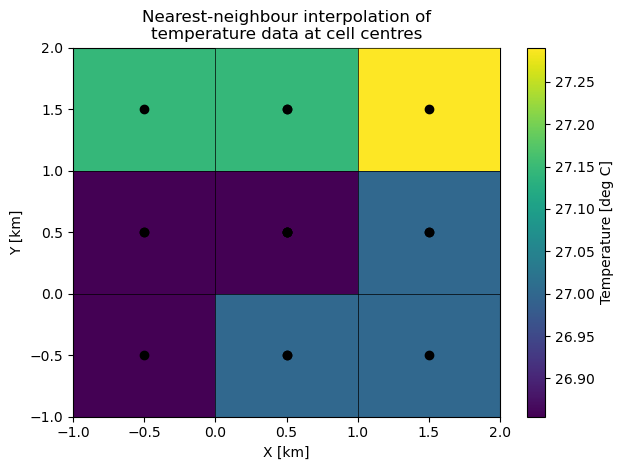

In [33]:
xcoords, ycoords = np.linspace(0,1,2), np.linspace(0,1,2)
xx, yy = np.meshgrid(xcoords, ycoords, indexing='ij')
data = 18 + np.random.rand(1)*np.array([[-1, 1], [0, 2]])

mm=5
# Paste the data at different locations to show the effect of nearest-neighbour interpolation
for i in [1,-1]:
    for j in [-1, 1]:
        plt.pcolormesh(xx + i*0.5, yy + j*0.5, data, shading='auto', cmap=plt.cm.viridis)
        plt.scatter(xx+ i*0.5, yy + j*0.5, c='k', zorder=20)
cb = plt.pcolormesh(xx+0.5, yy + 0.5, 18 + 0.5*data, shading='auto', cmap=plt.cm.viridis, zorder=10)

plt.title('Nearest-neighbour interpolation of\ntemperature data at cell centres')

plt.colorbar(cb, ax=plt.gca(), label='Temperature [deg C]')
plt.xlabel('X [km]')
plt.ylabel('Y [km]')
plt.axhline(-1, linewidth=0.5, color='k', zorder=30)
plt.axhline(0, linewidth=0.5, color='k', zorder=30)
plt.axhline(1, linewidth=0.5, color='k', zorder=30)
plt.axhline(2, linewidth=0.5, color='k', zorder=30)
plt.axvline(-1, linewidth=0.5, color='k', zorder=30)
plt.axvline(0, linewidth=0.5, color='k', zorder=30)
plt.axvline(1, linewidth=0.5, color='k', zorder=30)
plt.axvline(2, linewidth=0.5, color='k', zorder=30)

plt.xlim([-1,2])
plt.ylim([-1,2])
plt.tight_layout()
plt.show()

**Figure 4 - Nearest-neighbour interpolation of "grid cell averaged" data at cell centres.**

Your data may represent a value across a cell edge. For example, in (2D) Arakawa C-grid datasets, velocities are defined across an edge as they represent a "flux" across that cell edge. Additionally, these cell edges may not be aligned with the coordinate axes, and rather represent a velocity in the $i$ or $j$ direction.

For structured grids, [Blanke and Raynaud](<https://doi.org/10.1175/1520-0485(1997)027%3C1038:KOTPEU%3E2.0.CO;2>) proposed in 1997 to perform a 1D linear interpolation of the $i$ velocity in the $i$ direction, and similarly a 1D linear interpolation of the $j$ velocity in the $j$ direction. These velocities must then be rotated into meridional and zonal velocities, which Parcels handles under the hood. In such a case, your velocity field may look like figure 5.

This (uni)linear velocity interpolation is now often referred to as the Analytical interpolation scheme, and is what the [Ariane](https://ariane-code.cnrs.fr) and [TRACMASS](https://www.tracmass.org/index.html) Lagrangian codes also use. In Parcels, the time-stepping version of this interpolation is provided in the `CGrid_Velocity` Interpolator function.

```{note}
If you have a structured curvilinear grid, and your velocity field is oriented in the $i/j$-directions, then it is almost certain that your velocities are computed from fluxes across the cell edge, and that you will require the `CGRID_Velocity` Interpolator.
```

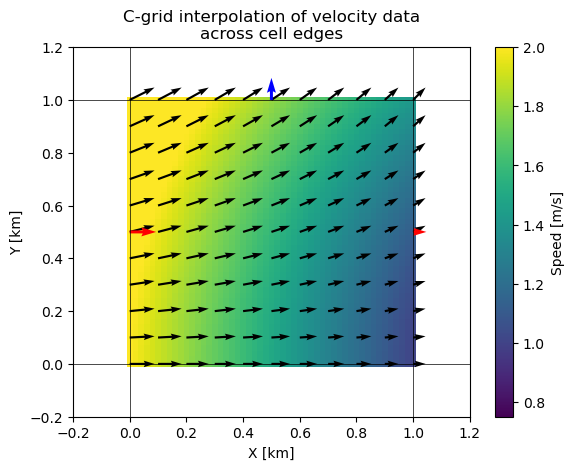

In [34]:
# Construct dummy data for velocity field at the cell edges of a single grid cell
u_data = np.array([[2, 1]])
v_data = np.array([[0, 1]])

interp_u = interp1d([0,1], u_data.flatten(), kind='linear')
interp_v = interp1d([0,1], v_data.flatten(), kind='linear')

interp_xx, interp_yy = np.linspace(0,1,51), np.linspace(0,1,51)
XX,YY = np.meshgrid(interp_xx, interp_yy, indexing='xy')

interp_u_data = interp_u(XX)
interp_v_data = interp_v(YY)
interp_speed_data = np.sqrt(interp_u_data**2 + interp_v_data**2)

# Plot the interpolated velocity vectors and speed data
mm=5
plt.axhline(0, linewidth=0.5, color='k')
plt.axvline(0, linewidth=0.5, color='k')
plt.axhline(1, linewidth=0.5, color='k')
plt.axvline(1, linewidth=0.5, color='k')

cb = plt.pcolormesh(interp_xx, interp_yy, interp_speed_data, vmin=0.75, vmax=2)
plt.quiver(interp_xx[::mm], interp_yy[::mm], interp_u_data[::mm,::mm], interp_v_data[::mm,::mm])
plt.quiver(interp_xx[0], interp_yy[len(interp_yy)//2], interp_u_data[len(interp_u_data)//2, 0], 0, color='r', scale=30)
plt.quiver(interp_xx[-1], interp_yy[len(interp_yy)//2], interp_u_data[len(interp_u_data)//2, -1], 0, color='r', scale=30)

plt.quiver(interp_xx[len(interp_yy)//2], interp_yy[0], 0, interp_v_data[0, len(interp_v_data)//2], color='b')
plt.quiver(interp_xx[len(interp_yy)//2], interp_yy[-1], 0, interp_v_data[-1, len(interp_v_data)//2], color='b')

plt.title('C-grid interpolation of velocity data\nacross cell edges')
plt.colorbar(cb, ax=plt.gca(), label='Speed [m/s]')
plt.xlim([-0.2,1.2])
plt.ylim([-0.2,1.2])
plt.xlabel('X [km]')
plt.ylabel('Y [km]')
plt.show()

**Figure 5 - C-grid 1D interpolation of velocity data defined across a cell edge.**


### Vertical coordinates

Lastly, a short note on vertical coordinates. Parcels can handle two styles of vertical coordinates; z-levels which define fixed depth levels in physical space, and sigma-levels which define varying depth levels in physical space as a function of the water column depth. As sigma-levels are effectively "terrain-following", the grid cell faces may no longer be orthogonal to the domain surface. Figure 1 visualises these differences, and parcels handles this all under the hood. See the CROCO Tutorial for more details on the sigma-levels implementation.
